In [1]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier()
xgb_model.load_model("../results/xgb.json")

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_train = pd.read_csv("../data/tep_train_100sims.csv")

X = df_train.drop("faultNumber", axis=1).astype("float32")
y = df_train["faultNumber"].astype("int8")

print("Splitting train and eval dataset...")
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"X_train = {len(X_train)}, X_val = {len(X_val)}, y_train = {len(y_train)}, y_val = {len(y_val)}")

Splitting train and eval dataset...
X_train = 840000, X_val = 210000, y_train = 840000, y_val = 210000


In [4]:
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_train, xgb_model.predict(X_train))
print(acc_train)

0.7993845238095239


In [3]:
from sklearn.metrics import classification_report

pred_val = xgb_model.predict(X_val)

report = classification_report(y_val, pred_val)
print(report)

              precision    recall  f1-score   support

           0       0.16      0.19      0.17     10000
           1       0.99      0.95      0.97     10000
           2       0.99      0.95      0.97     10000
           3       0.21      0.44      0.29     10000
           4       0.95      0.95      0.95     10000
           5       0.98      0.96      0.97     10000
           6       1.00      0.96      0.98     10000
           7       1.00      0.96      0.98     10000
           8       0.99      0.91      0.95     10000
           9       0.17      0.15      0.16     10000
          10       0.87      0.80      0.83     10000
          11       0.87      0.81      0.84     10000
          12       0.97      0.91      0.94     10000
          13       0.99      0.86      0.92     10000
          14       0.99      0.94      0.96     10000
          15       0.22      0.21      0.22     10000
          16       0.97      0.77      0.86     10000
          17       0.97    

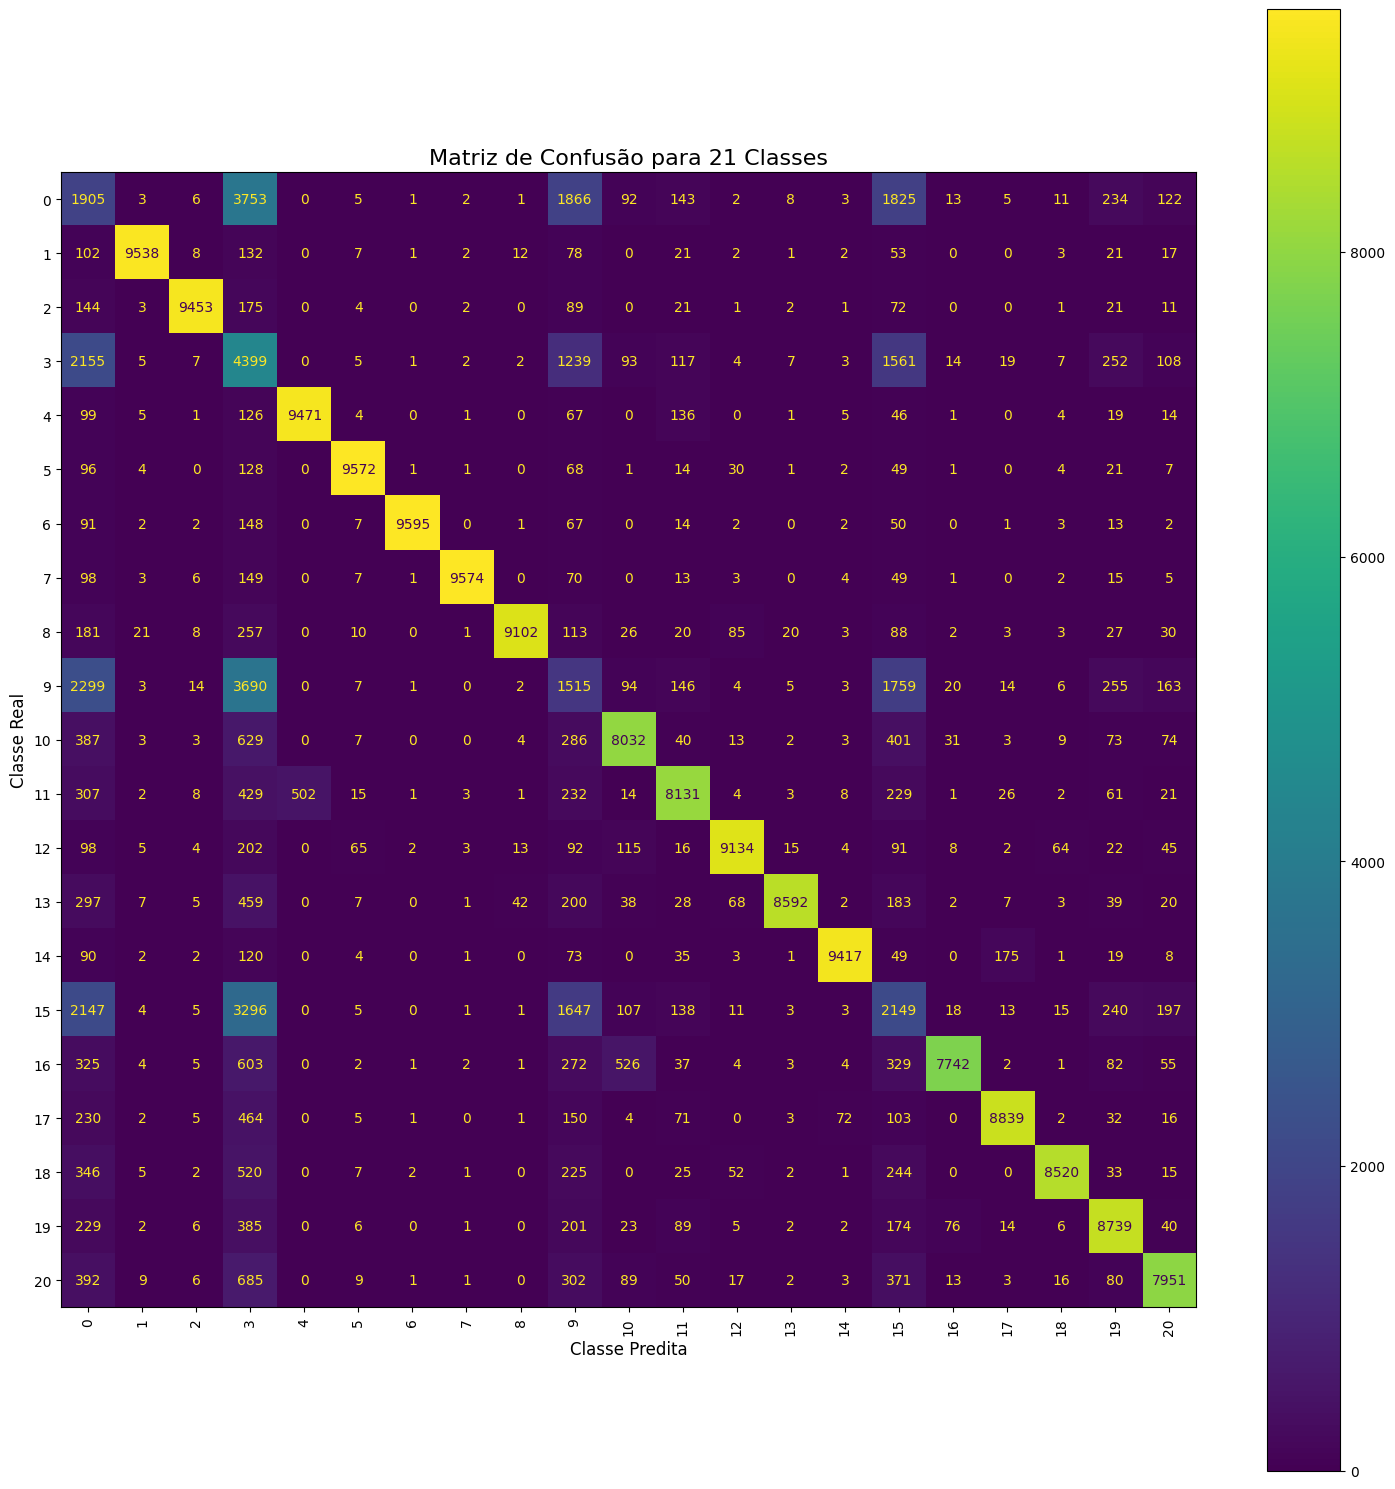

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(15, 15))

disp = ConfusionMatrixDisplay.from_predictions(
    y_val, 
    pred_val,
    ax=ax,
    cmap="viridis",
    colorbar=True
)

plt.xticks(rotation=90)
plt.yticks(rotation=0) # Garante que os y-labels fiquem na horizontal

# 4. Melhore a legibilidade geral
ax.set_title('Matriz de Confusão para 21 Classes', fontsize=16)
ax.set_xlabel('Classe Predita', fontsize=12)
ax.set_ylabel('Classe Real', fontsize=12)

# Opcional: Ajuste o layout para não cortar as bordas
plt.tight_layout()

plt.show()